# Hydrodynamic Nonlinear Convergence


Evolution diagnostics for nonlinear hydrodynamic runs.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size':18})


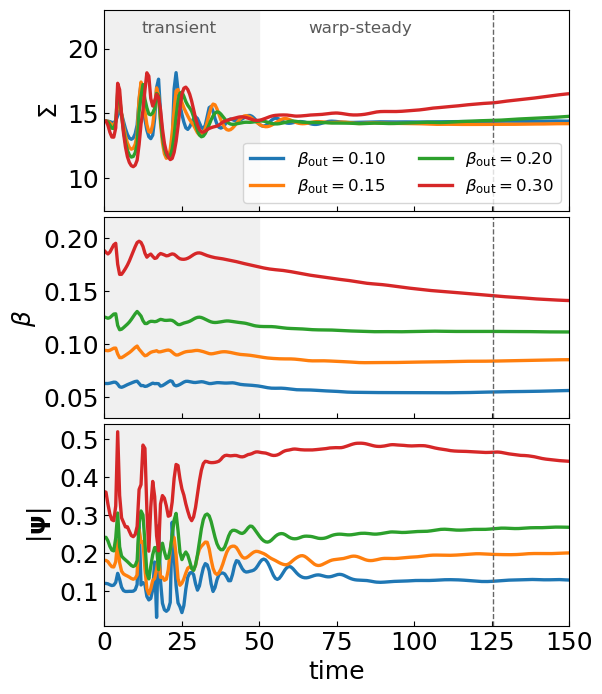

In [3]:
fig, axs = plt.subplots(3, 1, figsize=(6, 8), sharex=True)
fig.subplots_adjust(hspace=0.03)

sim_list = ['sim0.10', 'sim0.15', 'sim0.20', 'sim0.30']

for sim_name in sim_list:
    data = np.load('../_production_constant_load_hhr/' + sim_name + '_time_evol.npy')
    time = data[:, 0, 0]
    r_sim = data[0, :, 1]

    i_r = np.argmax(r_sim > 1.5)
    Sigma_mid = data[:, i_r, 2]

    Lmag = np.sqrt(data[:, :, 3]**2 + data[:, :, 4]**2 + data[:, :, 5]**2)
    lx = data[:, :, 3] / Lmag
    ly = data[:, :, 4] / Lmag
    lz = data[:, :, 5] / Lmag

    beta = np.arccos(lz)
    beta_mid = beta[:, i_r]

    psi_x = np.gradient(lx, r_sim, axis=1) * r_sim
    psi_y = np.gradient(ly, r_sim, axis=1) * r_sim
    psi_z = np.gradient(lz, r_sim, axis=1) * r_sim
    psi_abs = np.sqrt(psi_x**2 + psi_y**2 + psi_z**2)
    psi_mid = psi_abs[:, i_r]

    beta_out = float(sim_name[-4:])
    kws = {
        'lw': 2.4,
        'label': rf'$\beta_{{\rm out}}={beta_out:.2f}$'
    }

    axs[0].plot(time, Sigma_mid, **kws)
    axs[1].plot(time, beta_mid, **kws)
    axs[2].plot(time, psi_mid, **kws)

for ax in axs:
    ax.axvspan(0, 50, color='0.94', zorder=0)
    ax.axvline(125.6, color='0.4', lw=1.0, ls='--')
    ax.tick_params(which='both', direction='in')
    #ax.minorticks_on()

axs[0].text(12, 21.2, 'transient', fontsize=12, color='0.35')
axs[0].text(66, 21.2, 'warp-steady', fontsize=12, color='0.35')

axs[2].set_xlabel('time')
axs[2].set_xlim(0, 150)

axs[0].set_ylim(7.5, 23.0)
axs[1].set_ylim(0.03, 0.22)
axs[2].set_ylim(0.01, 0.54)

axs[0].set_yticks([10, 15, 20])
axs[1].set_yticks([0.05, 0.10, 0.15, 0.20])
axs[2].set_yticks([0.1, 0.2, 0.3, 0.4, 0.5])

axs[0].set_ylabel(r'$\Sigma$')
axs[1].set_ylabel(r'$\beta$')
axs[2].set_ylabel(r'$|{\bf \psi}|$')

axs[0].legend(frameon=True,fontsize=12,ncol=2,loc=4)

#axs[0].legend(
#    frameon=False, fontsize=12, ncol=2,
#    loc='lower center', bbox_to_anchor=(0.5, 1.02)
#)
